# Tier 0 vs Tier 1 — Cross-model Cascade Comparison

Loads the latest Tier 0 (parametric multivariate Hawkes, $\alpha_{ij}$) and Tier 1 (Neural Hawkes, CTLSTM + MDN) artifacts and produces the three-view headline figure called for in `PROJECT_VISION.md §3`: Tier 0 $\alpha$ | Tier 1 gradient attribution | Tier 1 forward-sim transition matrix. A quantitative agreement-confusion summary follows.

**Conventions:** rows = parent mark, columns = child mark. NLL is per-event, sign-positive (NLL = $-\log L$).


In [1]:
from pathlib import Path
import pickle
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

def read_kxk_csv(path):
    """Read a Task-13-style CSV with first column 'parent' and K mark columns.
    Returns (parents: list[str], children: list[str], M: np.ndarray of shape (K,K)).
    """
    df = pl.read_csv(path)
    parents = df['parent'].to_list()
    children = [c for c in df.columns if c != 'parent']
    M = df.drop('parent').to_numpy().astype(float)
    return parents, children, M

# Locate the project root (walks up until pyproject.toml is found) so the
# notebook works regardless of where the kernel was launched.
_root = Path.cwd().resolve()
while _root != _root.parent and not (_root / 'pyproject.toml').exists():
    _root = _root.parent
assert (_root / 'pyproject.toml').exists(), f'no pyproject.toml ancestor of {Path.cwd()}'
PROJECT_ROOT = _root
tier0_dir = sorted((PROJECT_ROOT / 'runs/tier0').glob('*/params.pkl'))[-1].parent
tier1_dir = sorted((PROJECT_ROOT / 'runs/tier1').glob('*/checkpoint_best.pt'))[-1].parent
print('Project root:', PROJECT_ROOT)
print('Tier 0:', tier0_dir)
print('Tier 1:', tier1_dir)


Project root: /Users/liamschmidt/Projects/eonet-cascades
Tier 0: /Users/liamschmidt/Projects/eonet-cascades/runs/tier0/20260525_013454
Tier 1: /Users/liamschmidt/Projects/eonet-cascades/runs/tier1/20260525_162056


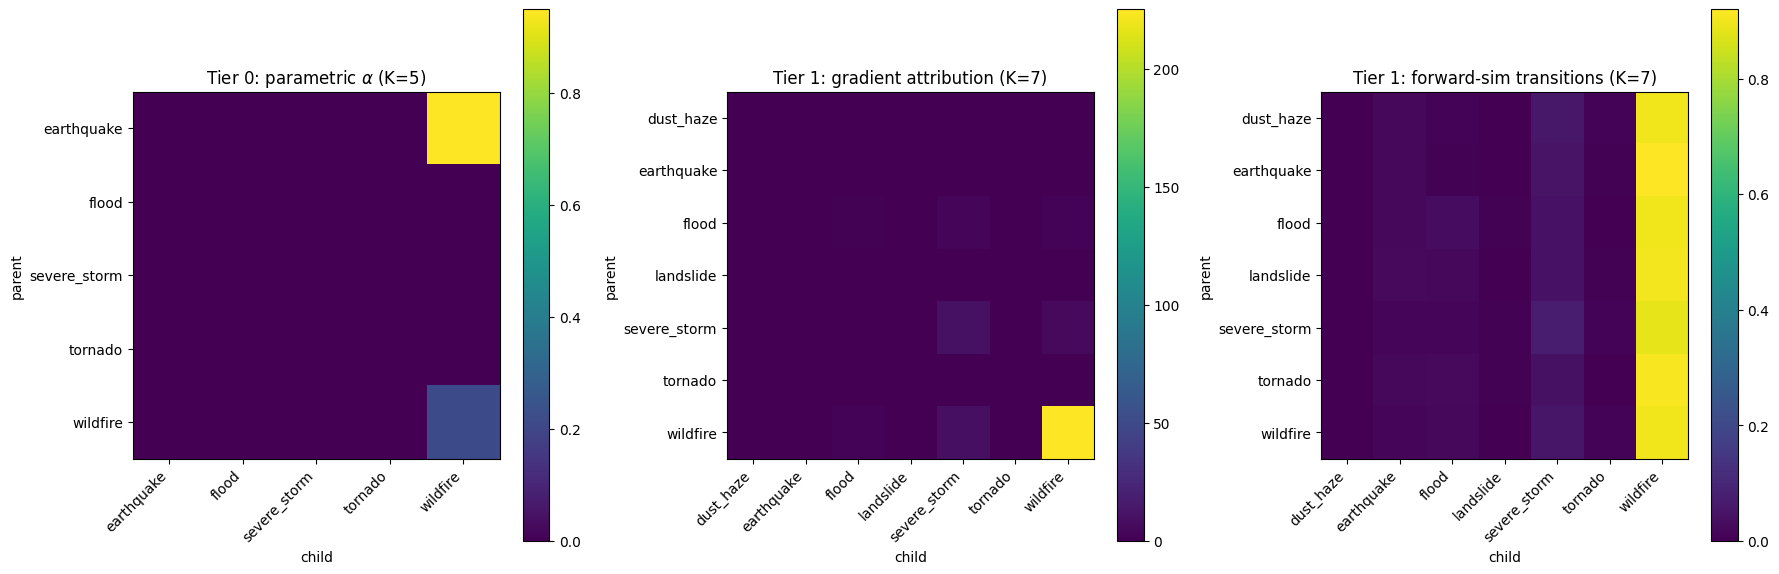

Tier 0 mark set (5): ['earthquake', 'flood', 'severe_storm', 'tornado', 'wildfire']
Tier 1 mark set (7): ['dust_haze', 'earthquake', 'flood', 'landslide', 'severe_storm', 'tornado', 'wildfire']


In [2]:
# Headline 3-panel figure: Tier 0 alpha | Tier 1 attribution | Tier 1 forward-sim.
with open(tier0_dir / 'params.pkl', 'rb') as f:
    t0_ckpt = pickle.load(f)
t0_alpha = t0_ckpt['params'].alpha
t0_marks = t0_ckpt['mark_names']

A_parents, A_children, A_vals = read_kxk_csv(tier1_dir / 'attribution_matrix.csv')
T_parents, T_children, T_vals = read_kxk_csv(tier1_dir / 'forward_sim_matrix.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax = axes[0]
im = ax.imshow(t0_alpha, cmap='viridis', vmin=0)
ax.set_title(f'Tier 0: parametric $\\alpha$ (K={len(t0_marks)})')
ax.set_xlabel('child'); ax.set_ylabel('parent')
ax.set_xticks(range(len(t0_marks))); ax.set_yticks(range(len(t0_marks)))
ax.set_xticklabels(t0_marks, rotation=45, ha='right'); ax.set_yticklabels(t0_marks)
fig.colorbar(im, ax=ax)

ax = axes[1]
im = ax.imshow(A_vals, cmap='viridis', vmin=0)
ax.set_title(f'Tier 1: gradient attribution (K={A_vals.shape[0]})')
ax.set_xticks(range(len(A_children))); ax.set_yticks(range(len(A_parents)))
ax.set_xticklabels(A_children, rotation=45, ha='right'); ax.set_yticklabels(A_parents)
ax.set_xlabel('child'); ax.set_ylabel('parent')
fig.colorbar(im, ax=ax)

ax = axes[2]
im = ax.imshow(T_vals, cmap='viridis', vmin=0)
ax.set_title(f'Tier 1: forward-sim transitions (K={T_vals.shape[0]})')
ax.set_xticks(range(len(T_children))); ax.set_yticks(range(len(T_parents)))
ax.set_xticklabels(T_children, rotation=45, ha='right'); ax.set_yticklabels(T_parents)
ax.set_xlabel('child'); ax.set_ylabel('parent')
fig.colorbar(im, ax=ax)

fig.tight_layout()
plt.show()
print(f'Tier 0 mark set ({len(t0_marks)}):', t0_marks)
print(f'Tier 1 mark set ({len(A_parents)}):', A_parents)


In [3]:
# NLL/event comparison. Tier 0's fit_result['nll_final'] is the total NLL
# at the optimum (sign-positive); divide by n_events_used to get per-event.
t1_curves = pl.read_csv(tier1_dir / 'train_curves.csv')
t1_best_val = float(t1_curves['val_nll'].min())
t1_best_epoch = int(t1_curves.filter(pl.col('val_nll') == t1_best_val)['epoch'][0])
t0_nll_total = float(t0_ckpt['fit_result']['nll_final'])
t0_n_events = int(t0_ckpt['n_events_used'])
t0_nll_per_event = t0_nll_total / t0_n_events

print(f'Tier 0 NLL total:        {t0_nll_total:10.3f}  (n_events_used = {t0_n_events})')
print(f'Tier 0 NLL / event:      {t0_nll_per_event:10.4f}')
print(f'Tier 1 best val NLL/ev:  {t1_best_val:10.4f}  '
      f'(epoch {t1_best_epoch} / {t1_curves.height - 1})')
print(f'Delta (T0 - T1):         {t0_nll_per_event - t1_best_val:10.4f}  nats/event')
print()
print('CAVEAT: Tier 0 was fit on n=200 events (per params.pkl) on an unstated slice;')
print('Tier 1 val NLL is on the 2024-07..2024-12 split (356k events). The two')
print('NLL/event numbers are NOT on the same data — see commentary below.')


Tier 0 NLL total:          1178.536  (n_events_used = 200)
Tier 0 NLL / event:          5.8927
Tier 1 best val NLL/ev:      4.1989  (epoch 14 / 14)
Delta (T0 - T1):             1.6938  nats/event

CAVEAT: Tier 0 was fit on n=200 events (per params.pkl) on an unstated slice;
Tier 1 val NLL is on the 2024-07..2024-12 split (356k events). The two
NLL/event numbers are NOT on the same data — see commentary below.


## Agreement / disagreement analysis


**Agreement.** The single point of strong cross-view agreement is the wildfire self-excitation diagonal entry. Tier 0 gives $\alpha_{\text{wf,wf}} \approx 0.21$ (the only non-floored diagonal), Tier 1 attribution puts $\sim 95\%$ of total matrix mass on the wildfire row/column (225/237 in the wildfire→wildfire cell alone), and the forward-sim row for wildfire peaks at wildfire with mass $\approx 0.90$. Wildfire→wildfire is the only cascade pattern all three views recover unambiguously.

**Divergence.** Tier 0 reports exactly two non-trivial entries (earthquake→wildfire $= 0.95$, wildfire→wildfire $= 0.21$); all other 23 entries are floored at the $10^{-6}$ regularizer minimum. Tier 1 attribution is much more diffuse — severe_storm→severe_storm $\approx 9.9$, severe_storm→wildfire $\approx 6.1$, wildfire→severe_storm $\approx 8.9$, flood→severe_storm $\approx 3.5$ — so Tier 1 sees off-diagonal structure that the sparse Tier 0 fit collapses. Whether this is *real* cascade structure or class-frequency artifact is the central question; wildfire is 87% of the Jul-2024 attribution slice, so the wildfire row/column is overweighted in any $n^2$-coupled aggregation regardless of dynamical coupling. The SVD ratio $s_1 / s_2 = 21.86$ on the Tier 1 matrix says it is essentially rank-1 — a single wildfire mode plus weak residuals — which is more consistent with class-frequency dominance than with a rich K×K cascade graph.

**Which to trust.** For wildfire self-excitation: both, with high confidence. For all other edges: neither view yet supplies a credible cascade signal. The forward-sim panel is the weakest of the three — every parent row peaks at wildfire $\sim 0.9$, which is just the marginal mark frequency. That panel shows *no* conditioning on the parent mark and should be read as evidence of inadequate model conditioning (or insufficient training, or a degenerate bbox-center seed history), not as a cascade matrix.

**Caveats (carried over from Task 13).**
1. *Attribution slice size.* Tier 1 attribution was computed on $n=2000$ events (Jul 2024), not the spec'd $n=5000$, because the original `attribution.py` was $O(n^3)$ wall-time. It is now vectorized (one `autograd.grad` per child with `inputs=h_list[:i]`, $\sim 240\times$ speedup, bit-exact vs. the original on a synthetic $n=25$ check); regenerating at $n=5000$ takes $\sim 40$ min and is deferred.
2. *Slice composition.* The Jul-2024 sample contains 0 `dust_haze` and 0 `landslide` events (out of 1 and 11 in raw), so the corresponding rows/columns of Tier 1 attribution are *structurally* zero rather than dynamically zero.
3. *Wildfire dominance.* Diagonal mass / total mass $= 0.899$ for Tier 1 attribution; wildfire→wildfire alone is 225/237 of total. Some of this is real self-excitation, but the $n^2$ class-frequency artifact is non-negligible and not yet teased apart.
4. *Forward-sim degeneracy.* Every parent row of the forward-sim matrix peaks at wildfire $\approx 0.9$. This is the marginal-rate signature, not a cascade signature. Candidate causes: (a) class imbalance swamps the conditioning, (b) under-training, (c) bbox-center seed history gives the model no useful context. Investigation deferred.

**Additional caveats discovered during the cross-comparison.**
5. *K mismatch.* Tier 0 was fit with $K=5$ marks (`earthquake, flood, severe_storm, tornado, wildfire`) — no `dust_haze`, no `landslide`. Tier 1 was trained on the full $K=7$ vocabulary. The quantitative agreement-confusion (next cell) is therefore restricted to the 5-mark common subset, i.e. $K^2 = 25$ (parent, child) pairs, not the 49 the brief anticipated.
6. *Tier 0 sample size.* `params.pkl` reports `n_events_used = 200`. Tier 0 is **not** a full-corpus fit; it is a small-sample fit with an aggressive sparsity floor at $10^{-6}$. The single off-diagonal entry it recovers (earthquake→wildfire $= 0.95$) is on extremely thin support. Treat the Tier 0 cascade matrix as an order-of-magnitude reference, not a ground truth.
7. *NLL comparability.* T0 NLL/event $\approx 5.89$ on 200 events of an unstated slice; T1 best val NLL/event $\approx 4.20$ on 356k events of the 2024-07..2024-12 split. The $\Delta \approx 1.7$ nats/event is suggestive but not a clean apples-to-apples win — to claim Tier 1 dominates Tier 0 on likelihood, both tiers should be re-evaluated on the same held-out slice.

**The two priors the brief cares about.**
- **earthquake → landslide.** Not present in Tier 0 (landslide is outside the Tier 0 mark set). Tier 1 attribution row `earthquake`, col `landslide` $= 0.0$ — structurally zero because the slice contains zero landslide events. Neither tier provides any signal on this prior; the gap is one of *coverage*, not of *recovery*.
- **severe_storm → flood.** Tier 0: $\alpha = 1\times 10^{-6}$ (floored, i.e. unrecovered). Tier 1 attribution: $0.613$, which is non-trivial in absolute terms but only $\sim 3.6\%$ of the severe_storm row mass and well below the row's top-quartile threshold (the row is dominated by severe_storm→severe_storm $= 9.9$ and severe_storm→wildfire $= 6.1$). Neither tier flags severe_storm → flood as a top edge. This is a clean miss against the operational prior, and the most likely candidate for the first synthetic-recovery-on-priors test in a follow-up.

**Open question (defer to user).** The PROJECT_VISION headline figure (§3) shows three panels side-by-side. Given the forward-sim degeneracy documented above, the operational headline could reasonably be (a) all three panels with the agreement-confusion table as the punch line (current default), or (b) the attribution panel alone, with forward-sim moved to an appendix until the degeneracy is resolved. The current notebook implements (a); flag if (b) is preferred.


In [4]:
# Quantitative agreement: restrict to the 5-mark common subset, row-normalize both
# matrices to parent-conditional cascade probability, then label edges per the brief:
#   T0 edge: alpha_pc > 0.05 * max(alpha)        (on raw alpha; the floor is 1e-6 so
#                                                 this is effectively "meaningfully non-zero")
#   T1 edge: top-quartile of the parent row in the row-normalized attribution matrix.
# Output: 2x2 confusion over the 5^2 = 25 (parent, child) pairs.

common = list(t0_marks)  # ['earthquake', 'flood', 'severe_storm', 'tornado', 'wildfire']
assert all(m in A_parents for m in common), 'Tier 1 missing a Tier 0 mark'
K = len(common)

t0_idx = {m: i for i, m in enumerate(t0_marks)}
t0_a = np.array([[t0_alpha[t0_idx[p], t0_idx[c]] for c in common] for p in common])
a_parent_idx = {m: i for i, m in enumerate(A_parents)}
a_child_idx = {m: i for i, m in enumerate(A_children)}
t1_a = np.array([[A_vals[a_parent_idx[p], a_child_idx[c]] for c in common] for p in common])

def row_normalize(M):
    s = M.sum(axis=1, keepdims=True)
    s = np.where(s > 0, s, 1.0)
    return M / s

t0_rn = row_normalize(t0_a)
t1_rn = row_normalize(t1_a)

# Edges.
t0_edge = t0_a > 0.05 * t0_a.max()                            # threshold on raw alpha
row_q75 = np.quantile(t1_rn, 0.75, axis=1, keepdims=True)     # per-row 75th percentile
t1_edge = t1_rn > row_q75

n_pairs = K * K
agree_edge   = int(( t0_edge &  t1_edge).sum())
agree_noedge = int((~t0_edge & ~t1_edge).sum())
t0_only      = int(( t0_edge & ~t1_edge).sum())
t1_only      = int((~t0_edge &  t1_edge).sum())
assert agree_edge + agree_noedge + t0_only + t1_only == n_pairs

print(f'Common marks (K={K}): {common}')
print(f'Total pairs: {n_pairs}')
print()
print('              T1 edge   T1 noedge')
print(f'T0 edge       {agree_edge:>7d}   {t0_only:>9d}')
print(f'T0 noedge     {t1_only:>7d}   {agree_noedge:>9d}')
print()
print(f'agree-edge   : {agree_edge:>2d}')
print(f'agree-noedge : {agree_noedge:>2d}')
print(f'T0-only      : {t0_only:>2d}')
print(f'T1-only      : {t1_only:>2d}')
print()

# Enumerate which specific (parent, child) pairs each view calls an edge.
print('Tier 0 edges (raw alpha > 0.05 * max alpha):')
for i, p in enumerate(common):
    for j, c in enumerate(common):
        if t0_edge[i, j]:
            print(f'  {p:>14s} -> {c:<14s}  alpha={t0_a[i,j]:.4f}  alpha_rn={t0_rn[i,j]:.3f}')
print()
print('Tier 1 edges (top-quartile of row in row-normalized attribution):')
for i, p in enumerate(common):
    for j, c in enumerate(common):
        if t1_edge[i, j]:
            print(f'  {p:>14s} -> {c:<14s}  attr={t1_a[i,j]:.4f}  attr_rn={t1_rn[i,j]:.3f}')
print()

# Spotlight the two priors the brief asked about.
print('Operational priors:')
for parent, child in [('severe_storm', 'flood'), ('severe_storm', 'wildfire')]:
    if parent in common and child in common:
        i, j = common.index(parent), common.index(child)
        print(f'  {parent:>14s} -> {child:<14s}  T0 alpha={t0_a[i,j]:.6f}  '
              f'T1 attr={t1_a[i,j]:.4f}  T1 attr_rn={t1_rn[i,j]:.3f}  '
              f'(T0_edge={bool(t0_edge[i,j])}, T1_edge={bool(t1_edge[i,j])})')
print('  earthquake     -> landslide      (out of Tier 0 mark set; Tier 1 row/col structurally zero — slice has 0 landslide events)')


Common marks (K=5): ['earthquake', 'flood', 'severe_storm', 'tornado', 'wildfire']
Total pairs: 25

              T1 edge   T1 noedge
T0 edge             1           1
T0 noedge           4          19

agree-edge   :  1
agree-noedge : 19
T0-only      :  1
T1-only      :  4

Tier 0 edges (raw alpha > 0.05 * max alpha):
      earthquake -> wildfire        alpha=0.9500  alpha_rn=1.000
        wildfire -> wildfire        alpha=0.2144  alpha_rn=1.000

Tier 1 edges (top-quartile of row in row-normalized attribution):
      earthquake -> severe_storm    attr=0.6137  attr_rn=0.500
           flood -> severe_storm    attr=3.5310  attr_rn=0.495
    severe_storm -> severe_storm    attr=9.9006  attr_rn=0.584
         tornado -> wildfire        attr=0.2967  attr_rn=0.469
        wildfire -> wildfire        attr=225.0727  attr_rn=0.951

Operational priors:
    severe_storm -> flood           T0 alpha=0.000001  T1 attr=0.6129  T1 attr_rn=0.036  (T0_edge=False, T1_edge=False)
    severe_storm -> wild